# Big Data Analytics Homework 03

*Complete this assignment in Google Colab. Prior to submitting a copy of this notebook (.ipynb format), run every cell and ensure you have corrected all runtime errors. Be sure to fill in your Name and SUID in the following cell. As always, you must do your own work. This means you may not use answers to the following questions generated by any other person or a generative AI tool such as ChatGPT. You may, however, discuss this assignment with others in a general way and seek help when you need it, but, again, you must do your own work.*

Name: Kent Roller

SUID: kdroller

## Medical Insurance Analysis
This assignment uses a medical insurance dataset with the following columns:
- **age**: Age of primary beneficiary
- **sex**: Female/Male
- **bmi**: Body mass index, providing an understanding of body weight relative to height, objective index of body weight (kg / m ^ 2) using the ratio of height to weight, ideally 18.5 to 24.9
- **children**: Number of children covered by health insurance / Number of dependents
- **smoker**: Is a smoker — yes/no
- **region**: The beneficiary's residential area in the US — northeast, southeast, southwest, northwest.
- **charges**: Individual medical costs billed by health insurance

## Setup

In [2]:
! pip install pyspark -q

In [35]:
# download the insurance data set
%%bash
if [[ ! -f insurance.csv ]]; then
 wget https://syr-bda.s3.us-east-2.amazonaws.com/insurance.csv -q
fi

In [36]:
from pyspark.sql import SparkSession
from pyspark import SparkContext

sc = SparkContext.getOrCreate()

spark = SparkSession\
    .builder\
    .appName('Homework 03')\
    .getOrCreate()

## Data Exploration

### Q1

Read the data into a Spark DataFrame named `insurance`. Column names should be age, sex, bmi, children, smoker, region, and charges. Print the resulting DataFrame schema and shape (number of rows, number of columns). Verify your schema makes sense. If the schema does not makes sense, fix it.

In [37]:
# your code here
#create the dataframe using the csv file downloaded
insurance = spark.read.csv('insurance.csv', header=True, inferSchema=True)

#Use Cast on the dataframe to make sure the column names are appropiatley named.
#Doing this here since specifically mentioned above
insurance = insurance.selectExpr(
    "CAST(age AS INT) AS age",
    "sex",
    "CAST(bmi AS DOUBLE) AS bmi",
    "CAST(children AS INT) AS children",
    'smoker',
    'region',
    'CAST(charges AS DOUBLE) AS charges'
)

# Show the dataframe to check the ouptut and make sure it is sensible
insurance.show()
#From the output below the dataframe seems to have expected column names

+---+------+------+--------+------+---------+-----------+
|age|   sex|   bmi|children|smoker|   region|    charges|
+---+------+------+--------+------+---------+-----------+
| 19|female|  27.9|       0|   yes|southwest|  16884.924|
| 18|  male| 33.77|       1|    no|southeast|  1725.5523|
| 28|  male|  33.0|       3|    no|southeast|   4449.462|
| 33|  male|22.705|       0|    no|northwest|21984.47061|
| 32|  male| 28.88|       0|    no|northwest|  3866.8552|
| 31|female| 25.74|       0|    no|southeast|  3756.6216|
| 46|female| 33.44|       1|    no|southeast|  8240.5896|
| 37|female| 27.74|       3|    no|northwest|  7281.5056|
| 37|  male| 29.83|       2|    no|northeast|  6406.4107|
| 60|female| 25.84|       0|    no|northwest|28923.13692|
| 25|  male| 26.22|       0|    no|northeast|  2721.3208|
| 62|female| 26.29|       0|   yes|southeast| 27808.7251|
| 23|  male|  34.4|       0|    no|southwest|   1826.843|
| 56|female| 39.82|       0|    no|southeast| 11090.7178|
| 27|  male| 4

### Q2

The features of this data set are `age`, `sex`, `bmi`, `children`, `smoker`, and `region`. The target variable is `charges`. For each numeric feature, calculate its correlation with the target variable.

Describe which variables are positively correlelated, which are negatively correlated, if the relationship is weak or strong, and if these observations align with your expectations. Be detailed in your explanation.

In [38]:
# your code here
#Could approach this in several ways, like if statement
#But will do it the easy way instead
#First, make a list of the column names that are numeric values
#In this case the values CAST as INT or Double
numeric_columns = ['age', 'bmi', 'children']

#Use for loop to iterate through list and find correlation
for col in numeric_columns:
  #use stat.corr to calculate correlation betweeen predictors and dependent variable
  correlation = insurance.stat.corr(col, 'charges')
  #display correlations in labled format
  print(f"Correlation between charges and {col}: {correlation}")

Correlation between charges and age: 0.299008193330648
Correlation between charges and bmi: 0.19834096883362903
Correlation between charges and children: 0.06799822684790492


*your written response here*
The correlation between the variables is displayed above. Interestingly none of the correlations are negative, which means, to some extent, each of the predictor variables has an influence on the dependent variable increasing. Here, the variable with the highest level of correlation is age. This signifies that the variable age has the largest effect on the overall cost, and that the older one gets, the more their cost will increase. When linear regression is performed the correlation coefficeient for each variable can be examined. The second variable with the highest correlation is bmi. This is somewhat lower than bmi but still a contributing factor to charges, here indicating that the higher the bmi the higher the charges would be. Children is the variable with the lowest amount of correlation meaning that children have the lowest amount of effect on the charges for medical care.

### Q3

Create two plots which highlight something interesting/surprising about this data set. Provide detailed written descriptions of each and describe what is interesting or suprising about them.

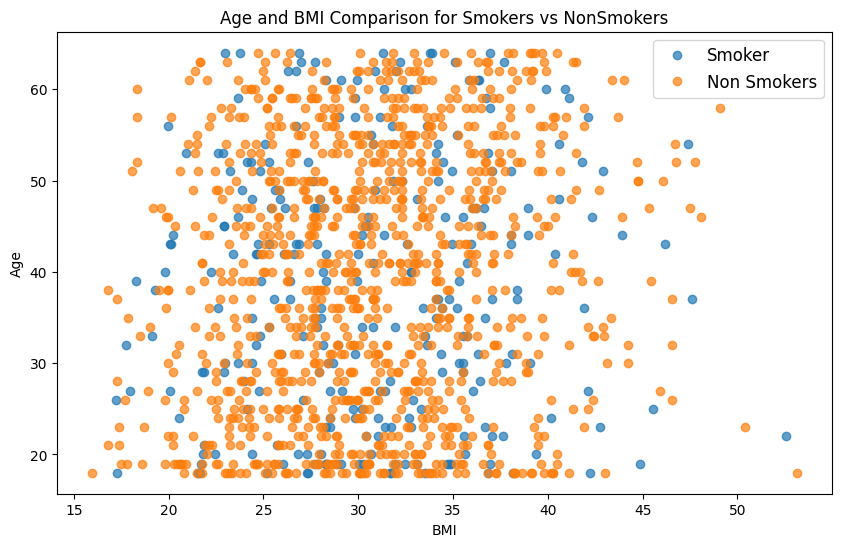

In [39]:
# your code for plot 1 here
#Make a plot comparing the bmi for smokers versus non smokers against age
import matplotlib.pyplot as plt


#Convert columns of interest to Pandas for plotting
plot_data = insurance.select("bmi", "age", "smoker").toPandas()

#Seperate smokers vs non smokers
smokers = plot_data[plot_data["smoker"]=="yes"]
non_smokers = plot_data[plot_data["smoker"]=="no"]

#make a plt
plt.figure(figsize=(10,6))

#Plot smoker data
plt.plot(smokers["bmi"], smokers["age"], "o", label="Smoker", alpha=0.7)

#Plot non smokers
plt.plot(non_smokers["bmi"], non_smokers["age"], "o", label="Non Smokers", alpha=0.7)

#Add labels to the plot
plt.title("Age and BMI Comparison for Smokers vs NonSmokers")
plt.xlabel("BMI")
plt.ylabel("Age")
plt.legend(fontsize=12)
#Display plot
plt.show()

*your description of plot 1 here*

In the figure shown above the age and bmi can be compared between the two groups smoker and non smoker. The y axis displays the Age while the x axis displays the BMI. Interestingly there does not seem to be any significant difference between the two groups as both groups exhibit a large amount of scatter throughout the plot. Likewise, there does not seem to be a strong correlation between age and bmi and there is no discernable linear pattern between the variables.



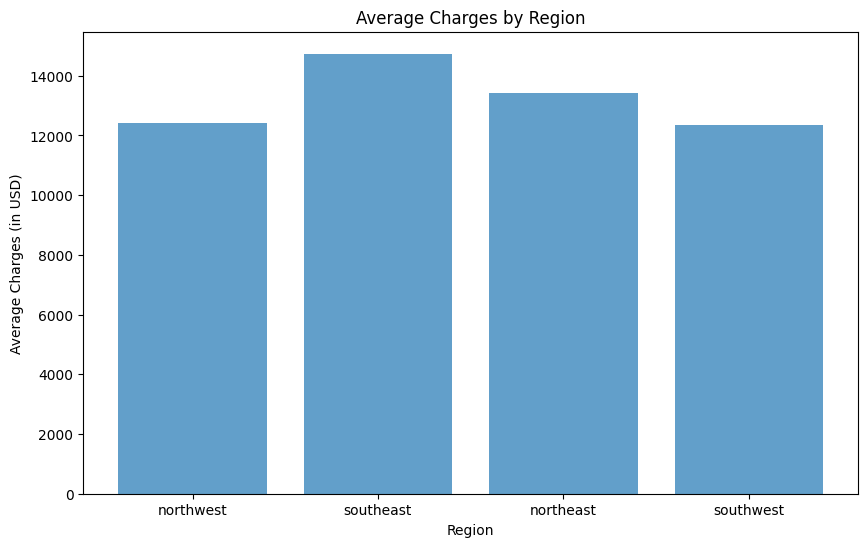

In [40]:
# your code for plot 2 here
#For this plot I will stick to something that can be displayed without using Pandas first

from pyspark.sql import functions as f

#Find the average charge for each region
avg_charges_by_region= (
    insurance.groupBy("region")
    .agg(f.avg("charges").alias("avg_charges"))
)

#Grab the results from above and put into a list
avg_cost_data = avg_charges_by_region.collect()

#Seperate the list out into it components (the coloumns) for plotting
regions= [row["region"] for row in avg_cost_data]
avg_charges=[row["avg_charges"] for row in avg_cost_data]

#Make the plt
plt.figure(figsize=(10,6))
#Specify the barplot
plt.bar(regions, avg_charges, alpha=0.7)

#Add labels to the plot
plt.title("Average Charges by Region")
plt.xlabel("Region")
plt.ylabel("Average Charges (in USD)")

#Show the plot
plt.show()

*your description of plot 2 here*
In the figure above the average charges for each region are shown. The southeast has the highest average charge, followed by the northeast region with the second highest average. Southwest and Northwest are third and fourth respectively. This indicated that the East has a higher charge rate than the west, and the south has the highest average charge out of the eastern regions. It should be noted that many factors may be influencing this such as the avergae age in the region, the average bmi in a region, and factors not considered in the dataset such as the average desnity of the population in each region or if the charge is due to cost of the care in the region and not due to extra demand of care in the region.

## Predict Insurance Charges with Linear Regression

### Q4

In this step you will perform feature engineering. The `insurance` data set is not yet ready for linear regression because some columns are categorical.

Create a new dataframe called `insurance_fe` which adds new feature engineered columns. Refer to previous labs on best practices to prepare your data for linear regression.

Encapsulate your feature engineering steps in a pipeline called `fe_pipe`. Explain each step you take and your reasons for doing so.

In [41]:
# your code here
#Import packages like OneHotEncoder and String Indexer
import pyspark.ml.feature as ml
from pyspark.ml import Pipeline


#Pick the categorical columns out for encoding
categorical_columns = ["sex", "region", "smoker"]

#Initialize variable called stages for storing pipeline
stages= []

#For each categorical value will use StringIndexer to create a numerical variable
#Could additionally do one hot encoding but since we are using regression we do
# no need to
# Additionally PySpark can recognize indexed columns as numercial columns for
#use in regression according to documentation
for col in categorical_columns:
  #Create index for observations
  indexer = ml.StringIndexer(inputCol=col, outputCol=f"{col}_index")
  #Insert observations into stages for further modification
  stages += [indexer]

#Create a pipeline for the process
fe_pipe = Pipeline(stages=stages)

#Fit the pipeline to the data (actually applying the index to the df)
fe_pipe_model = fe_pipe.fit(insurance)
insurance_fe = fe_pipe_model.transform(insurance)


*your explanation here*
First need to import the required pyspark packages that allow for string indexing and pipeline creation. Then we need to specify the catergorical columns so the index knows what to apply to. Then we use a for loop to iterate through the columns and create the index for each observation. After this, the action is stored in the stages variable. We then associate the Pipeline with the stages and finally apply the transromation to the dataset.

In [42]:
# do not modify
display(insurance_fe.show(10))

+---+------+------+--------+------+---------+-----------+---------+------------+------------+
|age|   sex|   bmi|children|smoker|   region|    charges|sex_index|region_index|smoker_index|
+---+------+------+--------+------+---------+-----------+---------+------------+------------+
| 19|female|  27.9|       0|   yes|southwest|  16884.924|      1.0|         2.0|         1.0|
| 18|  male| 33.77|       1|    no|southeast|  1725.5523|      0.0|         0.0|         0.0|
| 28|  male|  33.0|       3|    no|southeast|   4449.462|      0.0|         0.0|         0.0|
| 33|  male|22.705|       0|    no|northwest|21984.47061|      0.0|         1.0|         0.0|
| 32|  male| 28.88|       0|    no|northwest|  3866.8552|      0.0|         1.0|         0.0|
| 31|female| 25.74|       0|    no|southeast|  3756.6216|      1.0|         0.0|         0.0|
| 46|female| 33.44|       1|    no|southeast|  8240.5896|      1.0|         0.0|         0.0|
| 37|female| 27.74|       3|    no|northwest|  7281.5056|   

None

### Q5

Create a new pipeline named `lr_pipe` which encapsulates all the steps performed to create `fe_pipe`, any needed linear regression support objects, and a linear regression object.  Linear regression support objects are anything you need over and above what is in `fe_pipe` in order to successfully run linear regression.

Train and test `lr_pipe` using `insurance` (remember to split your data into train and test sets). To evaluate `lr_pipe`, use a built-in Spark evaluator object to compute MSE. Save the result in `lr_test_mse`.

In [43]:
#your code here
from pyspark.sql.functions import col, pow, mean
from pyspark.ml.regression import LinearRegression

#Initialize new feature columns for model
feature_cols=["age", "bmi", "children", "smoker_index", "sex_index", "region_index"]

#Create Vector Assembler to pull values from feature_cols and vectorize
va = ml.VectorAssembler(inputCols=feature_cols, outputCol="features")

#Intialize the Linear Regression model specifying the predictors (features)
#and dependent (charges) variables
lr = LinearRegression(featuresCol = 'features', labelCol = "charges")

#Create a pipe for previous steps
lr_pipe = Pipeline(stages = [va, lr])

#Use pipe to apply fitting of model to data
lr_model = lr_pipe.fit(insurance_fe)

#Display output from model to verify model
lr_model.transform(insurance_fe)\
  .show(5)

#Print model coefficients
print("Model Coefficients:", lr_model.stages[1].coefficients)

#Set up training, validation, and testing sets and split data accordingly
training_df, validation_df, testing_df= insurance_fe.randomSplit([0.6, 0.2, 0.2], seed=42)

#Train model on training data
lr_model_2=Pipeline(stages = [lr_pipe]).fit(training_df)

#Test model on testing data
predictions = lr_model_2.transform(testing_df)

#Calculate and output the MSE for the model
lr_test_mse = predictions.select(mean(pow(col("charges") - col("prediction"),2)).alias("mse")).collect()[0]["mse"]

+---+------+------+--------+------+---------+-----------+---------+------------+------------+--------------------+------------------+
|age|   sex|   bmi|children|smoker|   region|    charges|sex_index|region_index|smoker_index|            features|        prediction|
+---+------+------+--------+------+---------+-----------+---------+------------+------------+--------------------+------------------+
| 19|female|  27.9|       0|   yes|southwest|  16884.924|      1.0|         2.0|         1.0|[19.0,27.9,0.0,1....| 25802.49362767054|
| 18|  male| 33.77|       1|    no|southeast|  1725.5523|      0.0|         0.0|         0.0|[18.0,33.77,1.0,0...|3501.9118138370886|
| 28|  male|  33.0|       3|    no|southeast|   4449.462|      0.0|         0.0|         0.0|[28.0,33.0,3.0,0....| 6765.039296791185|
| 33|  male|22.705|       0|    no|northwest|21984.47061|      0.0|         1.0|         0.0|[33.0,22.705,0.0,...|3452.5446916117453|
| 32|  male| 28.88|       0|    no|northwest|  3866.8552|     

In [44]:
# do not modify
print(f'Linear regression test MSE: {lr_test_mse:.0f}')

Linear regression test MSE: 32543465


### Q6

Next, we want to perform inference using our linear regression model.

In the following cell, modify the pipeline above by adding a `StandardScaler` stage. Name this pipeline `lr_pipe_inf` (inf stands for inference).

Fit the model on the test data and print the MSE as you did above.

Answer: Does this model perform better than the previous model? Explain why or why not.

In [50]:
# your code here
#Same as above but now with new feature (Scaler)

#create feature column to specify predictors and use VectorAssembler to vectorize
feature_cols=["age", "bmi", "children", "smoker_index", "sex_index", "region_index"]
va = ml.VectorAssembler(inputCols=feature_cols, outputCol="features")

#Add scalar functionality
scaler = ml.StandardScaler(inputCol="features", outputCol="scaled_features")

#Intialize Linear Regression
lr = LinearRegression(featuresCol = 'scaled_features', labelCol = "charges")

#Combine steps into single pipe
lr_pipe_inf = Pipeline(stages = [va, scaler, lr])

#Fit pipe to dataset
lr_model_inf = lr_pipe_inf.fit(insurance_fe)

#Created split in data for training and testing
training_df, validation_df, testing_df= insurance_fe.randomSplit([0.6, 0.2, 0.2], seed=43)

#Fit Linear Regression model to training data
lr_model_3=Pipeline(stages = [lr_pipe_inf]).fit(training_df)

#Output values from training data to compare to previous step
lr_model_3.transform(training_df)\
  .show(5)

#Run model on testing data to check generalization performance
predictions_inf = lr_model_3.transform(testing_df)

#Output values from model for comparison
lr_model_3.transform(testing_df) \
  .show(5)
#Calculate MSE using method from above
lr_test_mse_inf = predictions_inf.select(mean(pow(col("charges") - col("prediction"),2)).alias("mse")).collect()[0]["mse"]

#Print Calculated MSE
print(f'Linear regression with Inference test MSE: {lr_test_mse_inf:.0f}')

+---+------+------+--------+------+---------+-----------+---------+------------+------------+--------------------+--------------------+------------------+
|age|   sex|   bmi|children|smoker|   region|    charges|sex_index|region_index|smoker_index|            features|     scaled_features|        prediction|
+---+------+------+--------+------+---------+-----------+---------+------------+------------+--------------------+--------------------+------------------+
| 18|female| 24.09|       1|    no|southeast|  2201.0971|      1.0|         0.0|         0.0|[18.0,24.09,1.0,0...|[1.28965726846848...| 197.9896436508643|
| 18|female| 25.08|       0|    no|northeast|  2196.4732|      1.0|         3.0|         0.0|[18.0,25.08,0.0,0...|[1.28965726846848...| 602.4830877181139|
| 18|female|29.165|       0|    no|northeast|7323.734819|      1.0|         3.0|         0.0|[18.0,29.165,0.0,...|[1.28965726846848...| 1923.499298517274|
| 18|female|30.115|       0|    no|northeast| 2203.47185|      1.0|   

*your answer here*
No this model does not perform better than the other. We know this as the MSE value for the second model using inference is worse than the first model which did not use inference. This indicates the data in the dataset is not appropriate for this method and another method should be used to model the data or to obtain better performance than Linear Regression without Inference. It also indicates that the data in the dataset has some level of skew in one or more of the predictors causing poor performance as Inference relies on normal distributions.

## Classification of High/Low Charges with Logistic Regression

### Q7

Next we will modify our target variable for classification.

Create a new dataframe named `insurance_stratefied` by adding a new column to `insurance_fe` named `rate_pool`.

Create the `rate_pool` column by stratifying the `charges` column into charges greater than and less than or equal to the median of the `charges` column. Assign an integer 0 to charges that are less than or equal to the median, and a 1 to charges greater than the median.

In [51]:
# your code here
#import when from sql functions
from pyspark.sql.functions import when

#Set up variable to store the median, use approxQuantile with the 0.5 argument to specify the median
charges_median = insurance_fe.approxQuantile("charges", [0.5], 0.0)[0]

#Create a new dataframe and then add the new column ratepool
insurance_stratefied = insurance_fe.withColumn(
    "rate_pool",
    #Specify when a value from the charges column should be converted to a 0 or
    # a 1 in the rate_pool column
    when(col("charges")<= charges_median, 0).otherwise(1)
)

In [52]:
# do not modify
insurance_stratefied.select('charges', 'rate_pool').show(10)

+-----------+---------+
|    charges|rate_pool|
+-----------+---------+
|  16884.924|        1|
|  1725.5523|        0|
|   4449.462|        0|
|21984.47061|        1|
|  3866.8552|        0|
|  3756.6216|        0|
|  8240.5896|        0|
|  7281.5056|        0|
|  6406.4107|        0|
|28923.13692|        1|
+-----------+---------+
only showing top 10 rows



### Q8

Create a new pipeline named `logistic_pipe` which predicts the `rate_pool` column in `insurance_stratefied`.

Train and test `logistic_pipe` using `insurance_stratefied`.  

Score `logistic_pipe` using a built-in Spark evaluator and an AUC (area under the ROC curve) scoring metric.

Your answer should print the test AUC from your model as "Test AUC score: XX.X%".


In [75]:
# your code
#import needed libraries
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

#set up a new training and test split for the stratefied data
training, testing = insurance_stratefied.randomSplit([0.7,0.3], seed=42)

#Initialize another vector assembler for the stratefied dataset
va_log = ml.VectorAssembler(inputCols=["age", "bmi", "children", "smoker_index", "sex_index", "region_index"], outputCol='features')

#Intialize Logistic regression for the pipeline using the features defined in the vector assembler
# and setting the label to the new column rate_pool which is the binarized charges column
log_reg= LogisticRegression(featuresCol="features", labelCol="rate_pool")

#Initialize the pipeline by utlizing the stages set up above
logistic_pipe = Pipeline(stages=[va_log, log_reg])

#Fit the logistic model using the pipeline to the training dataset
log_reg_model = logistic_pipe.fit(training)

#Now use the test data to get model evaluation
predictions_log = log_reg_model.transform(testing)

#Create evaluator for Binary Classification and use of ROC curve
evaluator = BinaryClassificationEvaluator(rawPredictionCol= 'rawPrediction',
                                          labelCol='rate_pool')
#Create ROC
roc_log_reg=evaluator.evaluate(predictions_log)
roc_log_reg=roc_log_reg*100
#Print ROC curve
print(f"Test AUC score: {roc_log_reg:.2f}%")


Test AUC score: 96.54%


### Q9

Print out the intercept and coefficients from your logistic regression model above as a Pandas data frame with columns `feature` and `coefficient`. Use this output to **manually calculate** a prediction for `rate_pool` for the **first observation** in the **test data**. Was the prediction correct?

**Hint:** You will want to use the `exp` function from `numpy` in your probability calculation.

In [66]:
# your code here
import pandas as pd
#Pull the features from the input columns in the vector assembler.
feature_names = feature_cols

#Pull the coefficients from the logistic regression model
coefficients = log_reg_model.stages[-1].coefficients.toArray()
#Pull the intercept from the model
intercept = log_reg_model.stages[-1].intercept

#Create a pandas dataframe
coefficients_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient" : coefficients
})

#Add intercepts to dataframe
coefficients_df= pd.concat([
    coefficients_df,
    pd.DataFrame({"feature": ["intercept"], "coefficient": [intercept]})
], ignore_index=True)

print(coefficients_df)


        feature  coefficient
0           age     0.152946
1           bmi     0.027019
2      children     0.094285
3  smoker_index    26.821767
4     sex_index     0.334681
5  region_index     0.226113
6     intercept    -8.495057


In [76]:
import numpy as np

# Extract feature values for the first observation
first_observation = insurance_fe.select(*feature_cols).first()
feature_values = np.array([first_observation[f] for f in feature_cols])

# Calculate the linear term (z)
z = intercept + np.dot(coefficients, feature_values)

# Calculate the probability using the sigmoid function
probability = (1 / (1 + np.exp(-z)))*100

print(f"Predicted probability for the first observation: {probability}")

Predicted probability for the first observation: 99.99999998712843


## Classification of High/Low Charges with Trees

### Q10

Perform the same classification task as above, but this time using Gradient Boosting Trees.

Train your model using a hyperparameter tuning grid and 3-fold cross validation, with parameters and parameter value ranges that are appropriate for GBT.

Print the test AUC, using the same format as above.

Then print out the values of your tuning parameters for your best model (found during the cross validation step). Print using a similar format as above, where it is clear which parameter value you are reporting.

There is code and comments provided below to help get you started.

In [71]:
# your code
# answer (using GBT)
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# model
#Initialize GBT classifier
gbt = GBTClassifier(featuresCol="features", labelCol="rate_pool", maxIter=10)
#Intialize vector assembler
va_gbt = ml.VectorAssembler(inputCols=["age", "bmi", "children", "smoker_index", "sex_index", "region_index"], outputCol="features")

# pipline
gbt_pipe = Pipeline(stages=[va_gbt, gbt])

# grid
paramGrid = ParamGridBuilder() \
  .addGrid(gbt.maxDepth, [5,10]) \
  .addGrid(gbt.maxIter, [10,20]) \
  .build()

# evaluator
evaluator_gbt = BinaryClassificationEvaluator(rawPredictionCol='rawPrediction', labelCol='rate_pool')

# crossvalidator
cv = CrossValidator(
    estimator= gbt_pipe,
    estimatorParamMaps=paramGrid,
    evaluator= evaluator_gbt,
    numFolds=3,
    seed=42
)
# fit model
cv_model = cv.fit(training)
predictions_gbt=cv_model.transform(testing)

# print test AUC
roc_gbt = evaluator.evaluate(predictions_gbt)

# get the best model
best_model = cv_model.bestModel.stages[-1]

# print out the best values for your hyperparameters
#print('Best value for Hyperparamter is: ', best_model._java_obj.stages(-1))
#Extract values stored in best_model
best_depth=best_model.getMaxDepth()
best_iter=best_model.getMaxIter()

#Print
print(f"Best value for depth: {best_depth}")
print(f"Best vlaue for Iterations: {best_iter}")

Best value for depth: 5
Best vlaue for Iterations: 10


### Q11

Print out the **first tree** from your best model. Then, **manually calculate** the prediction for `rate_pool` based on the model inputs for the **first observation** in the **test data** and the tree you chose.

In [72]:
# your code
first_tree = best_model.trees[0]

print("First Tree from the Best Model:")
print(first_tree.toDebugString)

First Tree from the Best Model:
DecisionTreeRegressionModel: uid=dtr_7f44f9139bf7, depth=5, numNodes=35, numFeatures=6
  If (feature 0 <= 49.5)
   If (feature 3 in {0.0})
    If (feature 0 <= 47.5)
     If (feature 5 in {0.0,1.0,2.0})
      If (feature 2 <= 4.5)
       Predict: -0.8457583547557841
      Else (feature 2 > 4.5)
       Predict: -0.2
     Else (feature 5 not in {0.0,1.0,2.0})
      If (feature 2 <= 0.5)
       Predict: -0.88
      Else (feature 2 > 0.5)
       Predict: -0.5
    Else (feature 0 > 47.5)
     If (feature 2 <= 0.5)
      If (feature 5 in {0.0,1.0,3.0})
       Predict: -1.0
      Else (feature 5 not in {0.0,1.0,3.0})
       Predict: -0.3333333333333333
     Else (feature 2 > 0.5)
      If (feature 2 <= 2.5)
       Predict: 0.05263157894736842
      Else (feature 2 > 2.5)
       Predict: 1.0
   Else (feature 3 not in {0.0})
    Predict: 1.0
  Else (feature 0 > 49.5)
   If (feature 0 <= 50.5)
    If (feature 2 <= 0.5)
     If (feature 1 <= 36.855000000000004)
   

*your calculation*